In [ ]:
#2.2 编程题（NumPy）
import numpy as np
import matplotlib.pyplot as plt

# 1. 创建 3x4 标准正态分布随机矩阵 X
np.random.seed(42)  # 固定随机种子，便于复现
X = np.random.randn(3, 4)
print("X (3x4):\n", X)

# 2. 创建 4x2 全1矩阵 Y
Y = np.ones((4, 2))
print("\nY (4x2):\n", Y)

# 3. 矩阵乘法 Z = X @ Y
Z = X @ Y
print("\nZ = X @ Y (3x2):\n", Z)

# 4. 输出第一行第二列交叉处元素（索引从0开始）
print("\nZ[0, 1] (第一行第二列):", Z[0, 1])
print("Z 的第二行所有元素:", Z[1, :])

# 5. Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print("\nFrobenius 范数 of Z:", fro_norm)

X (3x4):
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y (4x2):
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X @ Y (3x2):
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z[0, 1] (第一行第二列): 2.5291682463487657
Z 的第二行所有元素: [1.87835721 1.87835721]

Frobenius 范数 of Z: 4.616873319476864


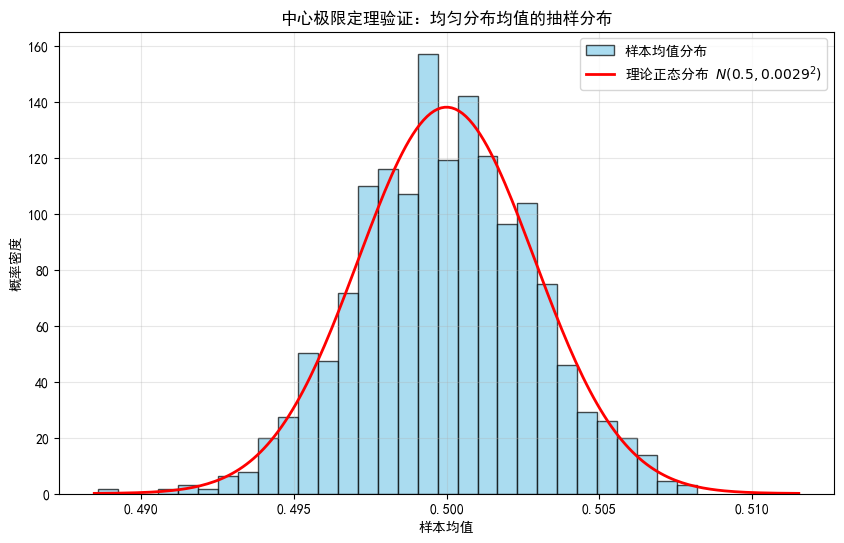

In [6]:
#3.2 中心极限定理模拟
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 解决中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

n = 10000
m = 1000
sample_means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

mu_theory = 0.5
sigma_theory = np.sqrt((1/12)/n)

plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, alpha=0.7,
         color='skyblue', edgecolor='black', label='样本均值分布')

x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 200)
pdf_theory = norm.pdf(x, mu_theory, sigma_theory)
plt.plot(x, pdf_theory, 'r-', linewidth=2,
         label=f'理论正态分布 $N({mu_theory}, {sigma_theory:.4f}^2)$')  # 使用 LaTeX 上标

plt.title('中心极限定理验证：均匀分布均值的抽样分布')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

均匀分布U(0,1)的方差为1/12，均值的方差为1/12/n。

手动前向结果：
a = 3.0, b = 3.5, L = 12.25

手动计算梯度：
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

PyTorch 自动梯度：
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0

梯度验证通过！


d:\qy\conda\envs\qqy\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


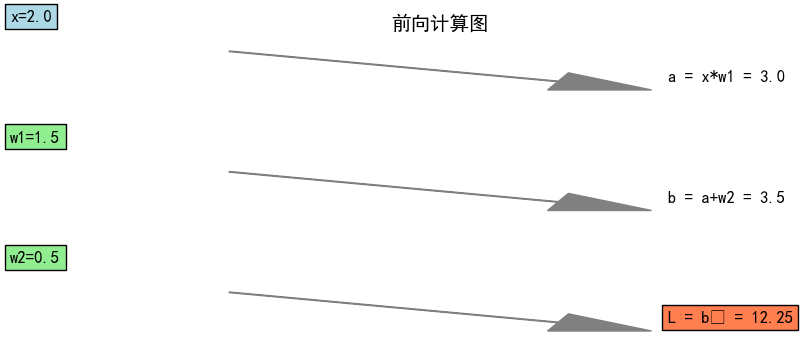

In [8]:
#4.2 手动反向传播与自动微分验证
import torch
import matplotlib.pyplot as plt

#手动前向与反向计算
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2
print("手动前向结果：")
print(f"a = {a}, b = {b}, L = {L}")

# 手动梯度
dL_db = 2 * b          # = 7
db_da = 1
db_dw2 = 1
da_dw1 = x

dL_dw1 = dL_db * db_da * da_dw1   # 7 * 1 * 2 = 14
dL_dw2 = dL_db * db_dw2           # 7 * 1 = 7
print("\n手动计算梯度：")
print(f"∂L/∂w1 = {dL_dw1}")
print(f"∂L/∂w2 = {dL_dw2}")

# ----- 使用 PyTorch 自动微分验证 -----
x_t = torch.tensor(2.0)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print("\nPyTorch 自动梯度：")
print(f"∂L/∂w1 = {w1_t.grad.item()}")
print(f"∂L/∂w2 = {w2_t.grad.item()}")

# 验证一致
assert abs(dL_dw1 - w1_t.grad.item()) < 1e-6
assert abs(dL_dw2 - w2_t.grad.item()) < 1e-6
print("\n梯度验证通过！")

# 绘制计算图（简单文本图）
plt.figure(figsize=(6, 4))
plt.text(0.1, 0.8, f"x={x}", fontsize=12, bbox=dict(facecolor='lightblue'))
plt.text(0.1, 0.6, f"w1={w1}", fontsize=12, bbox=dict(facecolor='lightgreen'))
plt.text(0.1, 0.4, f"w2={w2}", fontsize=12, bbox=dict(facecolor='lightgreen'))
plt.text(0.4, 0.7, f"a = x*w1 = {a}", fontsize=12)
plt.text(0.4, 0.5, f"b = a+w2 = {b}", fontsize=12)
plt.text(0.4, 0.3, f"L = b² = {L}", fontsize=12, bbox=dict(facecolor='coral'))
plt.arrow(0.2, 0.75, 0.15, -0.05, head_width=0.03, fc='gray', ec='gray')
plt.arrow(0.2, 0.55, 0.15, -0.05, head_width=0.03, fc='gray', ec='gray')
plt.arrow(0.2, 0.35, 0.15, -0.05, head_width=0.03, fc='gray', ec='gray')
plt.title("前向计算图", fontsize=14)
plt.axis('off')
plt.show()

训练集大小: (1437, 64), 测试集大小: (360, 64)
Epoch 10/50, Loss: 0.4464, Test Acc: 0.9167
Epoch 20/50, Loss: 0.2950, Test Acc: 0.9417
Epoch 30/50, Loss: 0.2366, Test Acc: 0.9500
Epoch 40/50, Loss: 0.2035, Test Acc: 0.9528
Epoch 50/50, Loss: 0.1823, Test Acc: 0.9583


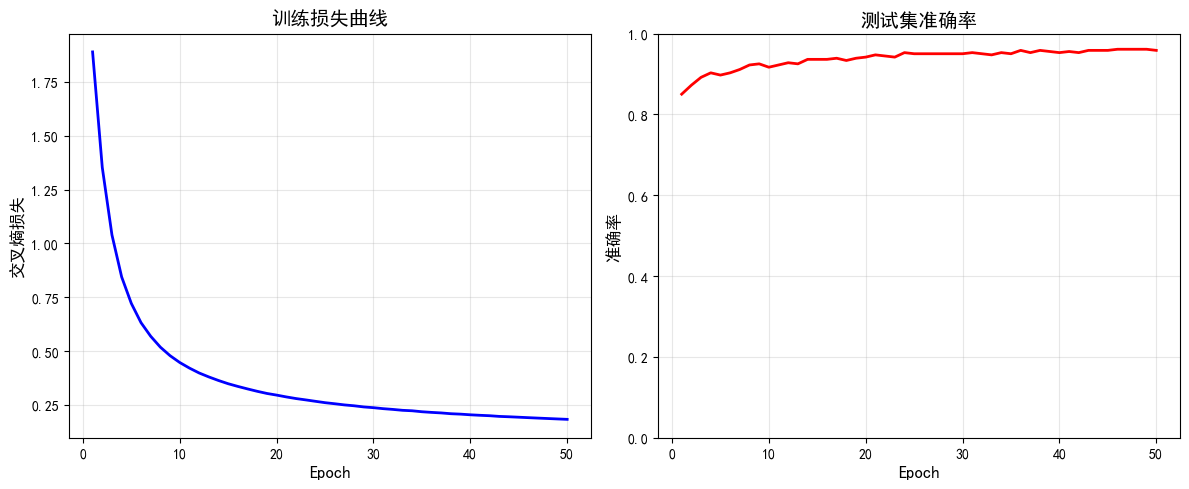


最终测试准确率: 95.83%


In [9]:
#5.2 Softmax 回归从零实现（MNIST 子集，带训练曲线和测试结果）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------
# 1. 加载数据并预处理
# ------------------------------
digits = load_digits()
X, y = digits.data, digits.target   # X: (1797, 64), y: (1797,)

# 归一化到 [0,1]
X = X / 16.0

# 划分训练集和测试集 (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# One-hot 编码标签
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

print(f"训练集大小: {X_train.shape}, 测试集大小: {X_test.shape}")

# ------------------------------
# 2. 定义 Softmax 和交叉熵损失
# ------------------------------
def softmax(logits):
    # 数值稳定版本
    max_logits = np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits - max_logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_onehot):
    # probs: (N, C), y_onehot: (N, C)
    N = probs.shape[0]
    loss = -np.sum(y_onehot * np.log(probs + 1e-8)) / N
    return loss

# ------------------------------
# 3. 小批量 SGD 训练
# ------------------------------
class SoftmaxRegression:
    def __init__(self, input_dim, num_classes, lr=0.1):
        self.W = np.random.randn(input_dim, num_classes) * 0.01
        self.b = np.zeros(num_classes)
        self.lr = lr

    def forward(self, X):
        logits = X @ self.W + self.b
        return softmax(logits)

    def compute_gradients(self, X, y_onehot):
        N = X.shape[0]
        probs = self.forward(X)
        # 梯度对 logits: (probs - y_onehot)
        dlogits = probs - y_onehot
        dW = (X.T @ dlogits) / N
        db = np.mean(dlogits, axis=0)
        return dW, db

    def update(self, dW, db):
        self.W -= self.lr * dW
        self.b -= self.lr * db

    def predict(self, X):
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

# 训练参数
epochs = 50
batch_size = 32
lr = 0.1

model = SoftmaxRegression(input_dim=64, num_classes=10, lr=lr)

# 记录损失和准确率
train_losses = []
test_accs = []

for epoch in range(epochs):
    # 每个 epoch 打乱训练数据
    indices = np.random.permutation(len(X_train))
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]

    epoch_loss = 0.0
    num_batches = 0

    # 小批量迭代
    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]

        dW, db = model.compute_gradients(X_batch, y_batch)
        model.update(dW, db)

        batch_loss = cross_entropy_loss(model.forward(X_batch), y_batch)
        epoch_loss += batch_loss
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)

    # 测试准确率
    y_pred = model.predict(X_test)
    acc = np.mean(y_pred == y_test)
    test_accs.append(acc)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")

# ------------------------------
# 4. 绘制训练曲线
# ------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, 'b-', linewidth=2)
plt.title('训练损失曲线', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('交叉熵损失', fontsize=12)
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), test_accs, 'r-', linewidth=2)
plt.title('测试集准确率', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('准确率', fontsize=12)
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n最终测试准确率: {test_accs[-1]*100:.2f}%")

Iter 200: loss = 0.015833
Iter 400: loss = 0.011645
Iter 600: loss = 0.009882
Iter 800: loss = 0.008846
Iter 1000: loss = 0.008139

测试集准确率: 100.00%


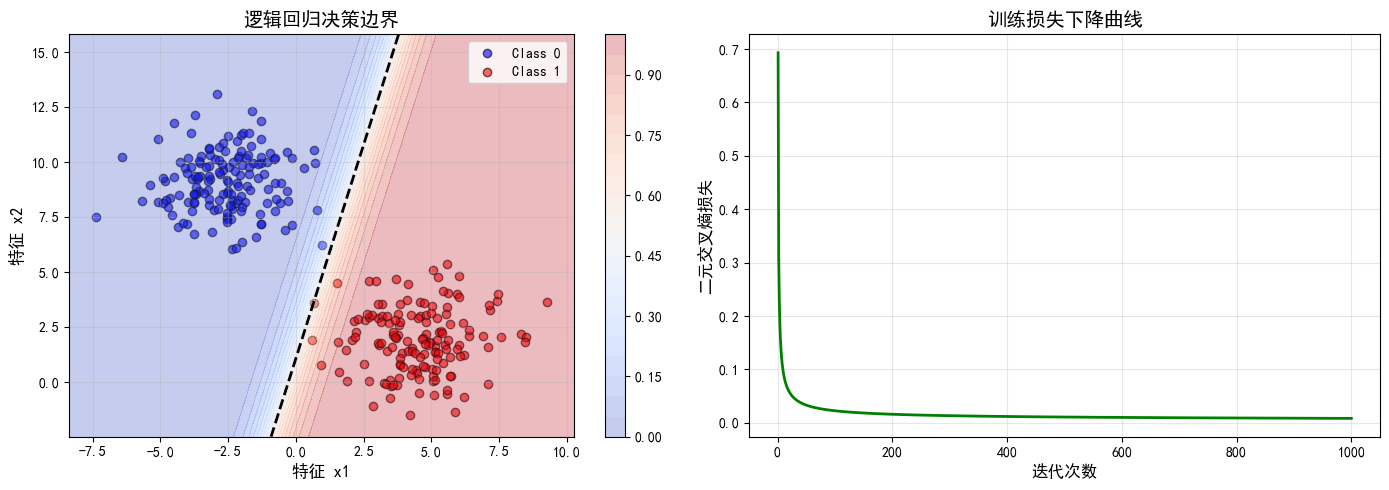

In [10]:
#6.2 逻辑回归二分类（线性可分数据，带决策边界可视化）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# ------------------------------
# 1. 生成线性可分数据
# ------------------------------
np.random.seed(42)
X, y = make_blobs(n_samples=400, n_features=2, centers=2, 
                  cluster_std=1.5, random_state=42)
# 将标签转为 0/1 (逻辑回归常用)
y = y.astype(float)   # 已经是 0/1

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ------------------------------
# 2. 定义 Sigmoid 和二元交叉熵损失
# ------------------------------
def sigmoid(z):
    z = np.clip(z, -500, 500)  # 防止溢出
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    # y_true: 0/1, y_pred: 概率
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# ------------------------------
# 3. 梯度下降训练
# ------------------------------
class LogisticRegression:
    def __init__(self, lr=0.1, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.w = None
        self.b = None
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for i in range(self.n_iter):
            # 前向
            linear = X @ self.w + self.b
            y_pred = sigmoid(linear)

            # 损失
            loss = binary_cross_entropy(y, y_pred)
            self.losses.append(loss)

            # 梯度
            dw = (1 / n_samples) * (X.T @ (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # 更新
            self.w -= self.lr * dw
            self.b -= self.lr * db

            if (i+1) % 200 == 0:
                print(f"Iter {i+1}: loss = {loss:.6f}")

    def predict_proba(self, X):
        linear = X @ self.w + self.b
        return sigmoid(linear)

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

# 训练模型
model = LogisticRegression(lr=0.1, n_iter=1000)
model.fit(X_train, y_train)

# 测试准确率
y_pred_test = model.predict(X_test)
acc = np.mean(y_pred_test == y_test)
print(f"\n测试集准确率: {acc*100:.2f}%")

# ------------------------------
# 4. 绘制决策边界和损失曲线
# ------------------------------
plt.figure(figsize=(14, 5))

# 子图1：决策边界 + 训练数据
plt.subplot(1, 2, 1)
# 画出训练集散点图
colors = ['blue', 'red']
for i, label in enumerate([0, 1]):
    plt.scatter(X_train[y_train == label, 0], X_train[y_train == label, 1],
                c=colors[i], label=f'Class {label}', alpha=0.6, edgecolors='k')

# 绘制决策边界： w0*x + w1*y + b = 0 即 x2 = -(w0*x1 + b)/w1
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2, linestyles='--')
plt.colorbar(plt.contourf(xx, yy, Z, levels=20, alpha=0.3, cmap='coolwarm'))
plt.title('逻辑回归决策边界', fontsize=14)
plt.xlabel('特征 x1', fontsize=12)
plt.ylabel('特征 x2', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

# 子图2：训练损失曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, len(model.losses)+1), model.losses, 'g-', linewidth=2)
plt.title('训练损失下降曲线', fontsize=14)
plt.xlabel('迭代次数', fontsize=12)
plt.ylabel('二元交叉熵损失', fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()